# Heron's Method (Babylonian Method)

## Iterative Square Root Calculation

This notebook implements **Heron's method** — one of the oldest known
algorithms for computing square roots. Given a positive number $S$, the
method produces a sequence of approximations $x_0, x_1, x_2, \dots$ that
converges rapidly to $\sqrt{S}$.

### Core idea

A rectangle with area $S$ has sides $x$ (width) and $S/x$ (height).
If $x \neq \sqrt{S}$, one side is too long and the other too short.
Averaging the two sides gives a better estimate — and the rectangle
becomes closer to a square with side length $\sqrt{S}$:

$$
x_{n+1} = \frac{1}{2}\!\left(x_n + \frac{S}{x_n}\right)
$$

---

## 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 2 — The Algorithm

### Step-by-step

1. **Choose** a radicand $S > 0$ and an initial guess $x_0 > 0$.

2. **Compute** the next approximation:
$$x_{n+1} = \frac{1}{2}\!\left(x_n + \frac{S}{x_n}\right)$$

3. **Check** convergence: stop when the relative change is small enough:
$$\frac{|x_{n+1} - x_n|}{x_{n+1}} < \varepsilon$$

4. **Repeat** from step 2 if not yet converged.

In [2]:
def heron(S, x0, tol=1e-6, max_iter=50):
    """
    Compute sqrt(S) using Heron's method.

    Parameters
    ----------
    S        : float – the radicand (must be > 0)
    x0       : float – initial guess (must be > 0)
    tol      : float – relative convergence tolerance
    max_iter : int   – safety limit on iterations

    Returns
    -------
    history : list of dict
        Each entry contains:
          n          – iteration index
          x_n        – current approximation (width)
          S_over_xn  – S / x_n  (height)
          x_next     – next approximation
          rel_error  – relative change |x_next - x_n| / x_next
          converged  – True if rel_error < tol
    """
    history = []
    x = x0

    for n in range(max_iter + 1):
        S_over_x  = S / x
        x_next    = 0.5 * (x + S_over_x)
        rel_error = abs(x_next - x) / x_next
        converged = rel_error < tol

        history.append({
            "n":         n,
            "x_n":       x,
            "S_over_xn": S_over_x,
            "x_next":    x_next,
            "rel_error":  rel_error,
            "converged": converged,
        })

        if converged:
            break
        x = x_next

    return history

## 3 — Formatted Output

In [3]:
def print_table(history, S):
    """Print a nicely formatted iteration table."""
    print(f"Heron's method for √{S}  (exact = {np.sqrt(S):.10f})")
    print("=" * 78)
    print(f"{'n':>3}  {'x_n':>16}  {'S / x_n':>16}  {'x_{n+1}':>16}  {'rel. error':>12}")
    print("-" * 78)
    for h in history:
        flag = "  ✓" if h["converged"] else ""
        print(f"{h['n']:>3}  {h['x_n']:>16.10f}  {h['S_over_xn']:>16.10f}  "
              f"{h['x_next']:>16.10f}  {h['rel_error']:>12.2e}{flag}")
    print("=" * 78)

## 4 — Run: $\sqrt{2}$ starting from $x_0 = 1$

In [5]:
S  = 2.0
x0 = 1.0

history = heron(S, x0, tol=1e-10)
print_table(history, S)

Heron's method for √2.0  (exact = 1.4142135624)
  n               x_n           S / x_n           x_{n+1}    rel. error
------------------------------------------------------------------------------
  0      1.0000000000      2.0000000000      1.5000000000      3.33e-01
  1      1.5000000000      1.3333333333      1.4166666667      5.88e-02
  2      1.4166666667      1.4117647059      1.4142156863      1.73e-03
  3      1.4142156863      1.4142114385      1.4142135624      1.50e-06
  4      1.4142135624      1.4142135624      1.4142135624      1.13e-12  ✓


Notice how quickly the number of correct digits roughly **doubles** at
each step — this is the hallmark of **quadratic convergence**.

## 5 — Convergence Plot

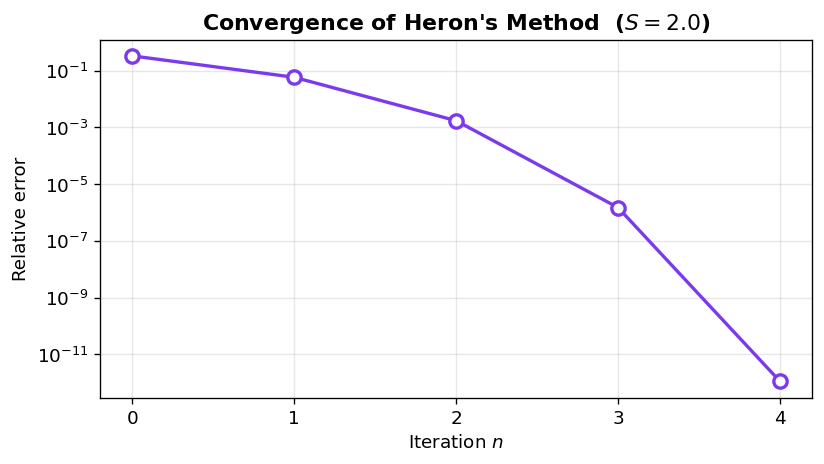

In [6]:
def plot_convergence(history, S):
    """Plot the relative error vs. iteration on a log scale."""
    ns     = [h["n"] for h in history]
    errors = [h["rel_error"] for h in history]

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.semilogy(ns, errors, "o-", color="#7c3aed", markersize=8, lw=2,
                markerfacecolor="white", markeredgewidth=2)

    ax.set_xlabel("Iteration $n$")
    ax.set_ylabel("Relative error")
    ax.set_title(f"Convergence of Heron's Method  ($S = {S}$)",
                 fontweight="bold")
    ax.set_xticks(ns)
    fig.tight_layout()
    plt.show()


plot_convergence(history, S)

## 6 — Geometric Visualisation

The rectangle with sides $x_n$ (width) and $S/x_n$ (height) has
area $S$ at every step. As the iteration converges, the rectangle
approaches a **square** with side $\sqrt{S}$.

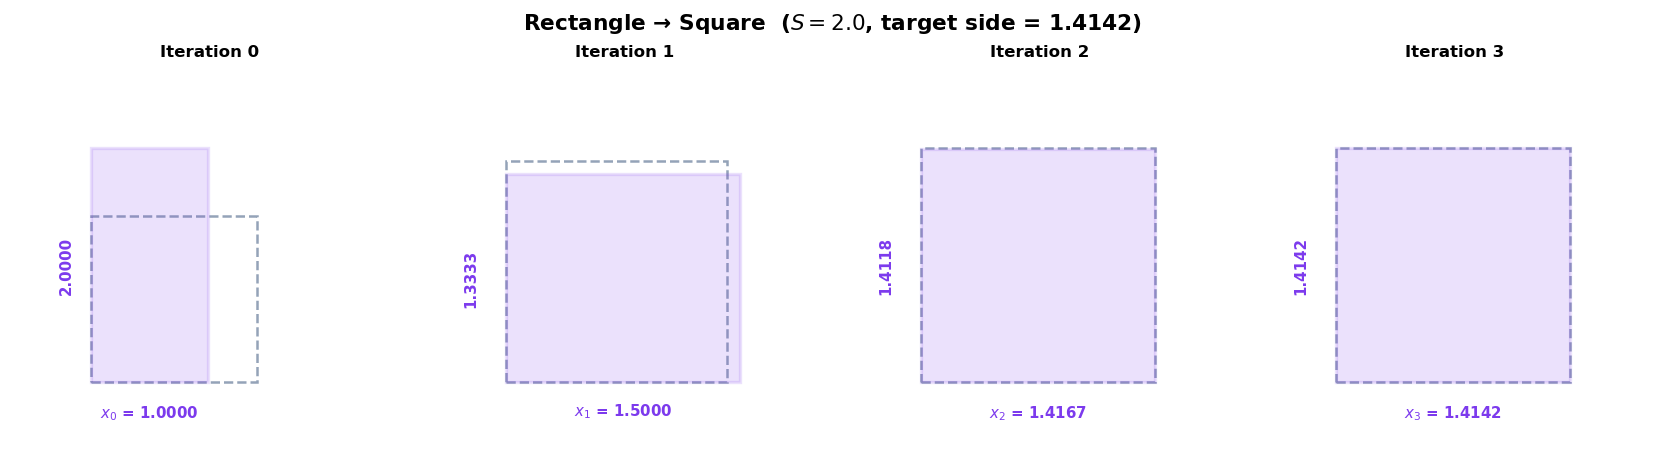

In [7]:
def plot_rectangles(history, S, steps_to_show=None):
    """
    Draw the rectangle at selected iterations, overlaid with
    the target square (dashed).
    """
    if steps_to_show is None:
        steps_to_show = list(range(len(history)))

    n_plots = len(steps_to_show)
    fig, axes = plt.subplots(1, n_plots, figsize=(3.5 * n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    sqrt_S = np.sqrt(S)

    for ax, idx in zip(axes, steps_to_show):
        h = history[idx]
        w = h["x_n"]
        h_rect = h["S_over_xn"]

        # Target square (dashed)
        sq = patches.Rectangle(
            (0, 0), sqrt_S, sqrt_S,
            linewidth=1.5, edgecolor="#94a3b8",
            facecolor="none", linestyle="--",
        )
        ax.add_patch(sq)

        # Current rectangle
        color = "#10b981" if h["converged"] else "#7c3aed"
        rect = patches.Rectangle(
            (0, 0), w, h_rect,
            linewidth=2, edgecolor=color,
            facecolor=color, alpha=0.15,
        )
        ax.add_patch(rect)

        # Labels
        ax.text(w / 2, -0.15 * max(h_rect, sqrt_S),
                f"$x_{idx}$ = {w:.4f}",
                ha="center", fontsize=9, color=color, fontweight="bold")
        ax.text(-0.15 * max(w, sqrt_S), h_rect / 2,
                f"{h_rect:.4f}",
                ha="center", va="center", fontsize=9, rotation=90,
                color=color, fontweight="bold")

        lim = max(w, h_rect, sqrt_S) * 1.35
        ax.set_xlim(-0.25 * lim, lim)
        ax.set_ylim(-0.25 * lim, lim)
        ax.set_aspect("equal")
        ax.set_title(f"Iteration {idx}", fontsize=10, fontweight="bold")
        ax.axis("off")

    fig.suptitle(f"Rectangle → Square  ($S = {S}$, target side = {sqrt_S:.4f})",
                 fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()


# Show first four iterations
plot_rectangles(history, S, steps_to_show=[0, 1, 2, 3])

## 7 — Effect of the Initial Guess

Even a wildly wrong initial guess converges in very few steps,
thanks to the quadratic convergence rate.

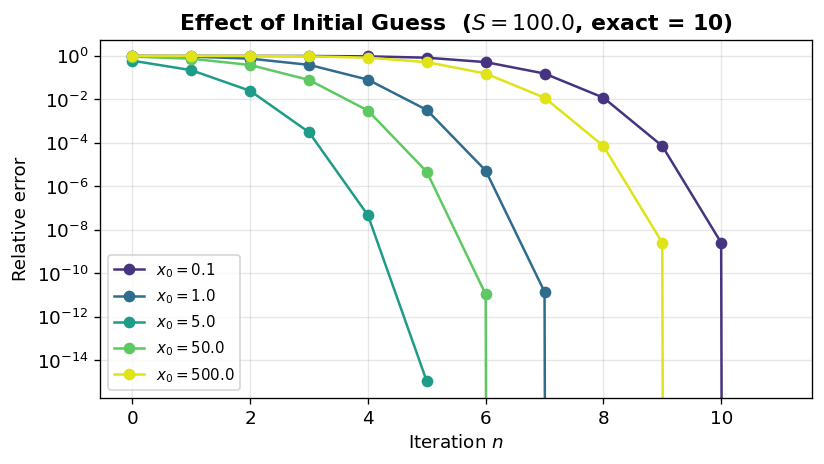

In [8]:
S = 100.0
guesses = [0.1, 1.0, 5.0, 50.0, 500.0]

fig, ax = plt.subplots(figsize=(7, 4))
cmap = plt.cm.viridis(np.linspace(0.15, 0.95, len(guesses)))

for x0, col in zip(guesses, cmap):
    h = heron(S, x0, tol=1e-12)
    ns     = [step["n"] for step in h]
    errors = [step["rel_error"] for step in h]
    ax.semilogy(ns, errors, "o-", color=col, lw=1.5, markersize=6,
                label=f"$x_0 = {x0}$")

ax.set_xlabel("Iteration $n$")
ax.set_ylabel("Relative error")
ax.set_title(f"Effect of Initial Guess  ($S = {S}$, exact = {np.sqrt(S):.0f})",
             fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 8 — Why It Works: Connection to Newton's Method

Finding $\sqrt{S}$ is equivalent to finding the root of

$$f(x) = x^2 - S$$

Newton's method for this function gives:

$$
x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)}
        = x_n - \frac{x_n^2 - S}{2\,x_n}
        = \frac{1}{2}\!\left(x_n + \frac{S}{x_n}\right)
$$

This is exactly Heron's formula! Because $f'(\sqrt{S}) \neq 0$ (simple root),
Newton's method guarantees **quadratic convergence**, i.e. the error
satisfies

$$
|e_{n+1}| \le C \cdot |e_n|^2
$$

which means the number of correct digits approximately doubles per step.

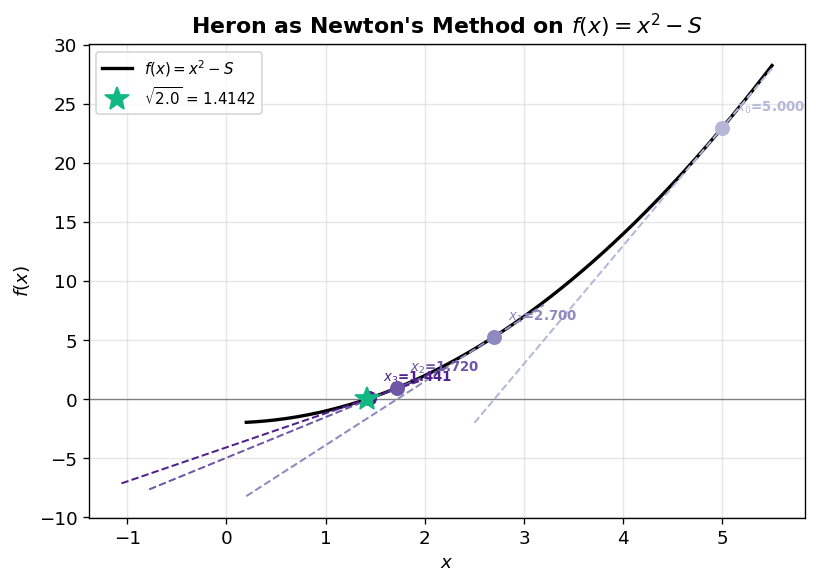

In [9]:
# Visualise Newton's method on f(x) = x² - S
S = 2.0
history = heron(S, x0=5.0, tol=1e-10)

x_plot = np.linspace(0.2, 5.5, 300)
f_plot = x_plot**2 - S

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_plot, f_plot, "k-", lw=2, label="$f(x) = x^2 - S$")
ax.axhline(0, color="grey", lw=0.8)

colors = plt.cm.Purples(np.linspace(0.4, 0.9, min(4, len(history))))

for i, (h, col) in enumerate(zip(history[:4], colors)):
    xn = h["x_n"]
    fn = xn**2 - S
    fpn = 2 * xn
    # Tangent line
    x_tan = np.linspace(xn - 2.5, xn + 0.5, 50)
    y_tan = fn + fpn * (x_tan - xn)
    ax.plot(x_tan, y_tan, color=col, lw=1.2, ls="--")
    ax.plot(xn, fn, "o", color=col, markersize=8, zorder=5)
    ax.annotate(f"$x_{i}$={xn:.3f}", (xn, fn),
                textcoords="offset points", xytext=(8, 10),
                fontsize=8, color=col, fontweight="bold")

ax.plot(np.sqrt(S), 0, "*", color="#10b981", markersize=15, zorder=6,
        label=f"$\\sqrt{{{S}}}$ = {np.sqrt(S):.4f}")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_title("Heron as Newton's Method on $f(x) = x^2 - S$",
             fontweight="bold")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 9 — Verifying Quadratic Convergence

If convergence is quadratic, then
$\log|e_{n+1}| \approx 2\,\log|e_n| + \text{const}$.
Plotting successive errors on a log–log scale should give a line
with slope $\approx 2$.

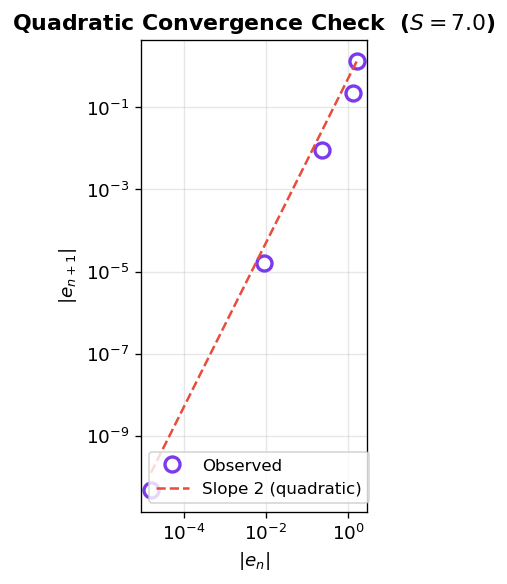

In [10]:
S = 7.0
history = heron(S, x0=1.0, tol=1e-15, max_iter=20)

exact = np.sqrt(S)
errors = [abs(h["x_n"] - exact) for h in history]

# Only use steps where both e_n and e_{n+1} are nonzero
e_n   = []
e_np1 = []
for i in range(len(errors) - 1):
    if errors[i] > 0 and errors[i + 1] > 0:
        e_n.append(errors[i])
        e_np1.append(errors[i + 1])

fig, ax = plt.subplots(figsize=(6, 5))
ax.loglog(e_n, e_np1, "o", color="#7c3aed", markersize=9,
          markerfacecolor="white", markeredgewidth=2, label="Observed")

# Reference line with slope 2
e_ref = np.logspace(np.log10(min(e_n)), np.log10(max(e_n)), 50)
C = e_np1[0] / e_n[0] ** 2
ax.loglog(e_ref, C * e_ref**2, "--", color="#e74c3c", lw=1.5,
          label="Slope 2 (quadratic)")

ax.set_xlabel("$|e_n|$")
ax.set_ylabel("$|e_{n+1}|$")
ax.set_title(f"Quadratic Convergence Check  ($S = {S}$)", fontweight="bold")
ax.legend(fontsize=10)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

## 10 — Summary Table for Various Radicands

In [11]:
radicands = [2, 3, 5, 7, 10, 100, 12345]

print(f"{'S':>8}  {'x0':>6}  {'iters':>5}  {'result':>18}  {'exact':>18}  {'abs. error':>12}")
print("-" * 78)

for S in radicands:
    x0 = S / 2.0 if S > 1 else 1.0
    h = heron(S, x0, tol=1e-12)
    result = h[-1]["x_next"]
    exact  = np.sqrt(S)
    err    = abs(result - exact)
    print(f"{S:>8}  {x0:>6.1f}  {len(h):>5}  {result:>18.12f}  {exact:>18.12f}  {err:>12.2e}")

       S      x0  iters              result               exact    abs. error
------------------------------------------------------------------------------
       2     1.0      6      1.414213562373      1.414213562373      2.22e-16
       3     1.5      5      1.732050807569      1.732050807569      0.00e+00
       5     2.5      5      2.236067977500      2.236067977500      0.00e+00
       7     3.5      5      2.645751311065      2.645751311065      0.00e+00
      10     5.0      6      3.162277660168      3.162277660168      4.44e-16
     100    50.0      8     10.000000000000     10.000000000000      0.00e+00
   12345  6172.5     11    111.108055513541    111.108055513541      0.00e+00


## 11 — Notes for Students

### Key take-aways

1. **Quadratic convergence** — The number of correct digits roughly
   doubles with each iteration. Even a terrible initial guess reaches
   machine precision in under 10 steps.

2. **Geometric interpretation** — Each step reshapes a rectangle of
   area $S$ so that its width and height become more equal. At
   convergence the rectangle is a square.

3. **Heron = Newton** — Heron's method is a special case of Newton's
   method applied to $f(x) = x^2 - S$. This connection explains
   the quadratic convergence rigorously.

4. **Robustness** — For $S > 0$ and $x_0 > 0$, the method *always*
   converges. After the very first step, $x_1 \ge \sqrt{S}$
   (the sequence overshoots and then decreases monotonically).

### Exercises

1. Modify the function to use an **absolute** stopping criterion
   $|x_{n+1} - x_n| < \varepsilon$ instead of a relative one.
   When does this make a difference?

2. Adapt the algorithm to compute **cube roots**:
   $$x_{n+1} = \frac{1}{3}\!\left(2\,x_n + \frac{S}{x_n^2}\right)$$
   Verify that this is Newton's method applied to $f(x) = x^3 - S$.

3. Count the number of iterations needed for $S = 2$ with
   $x_0 = 10^6$ and $\varepsilon = 10^{-12}$. Are you surprised?

4. Implement the algorithm using only **integer arithmetic**
   (i.e. compute $\lfloor\sqrt{S}\rfloor$ for integer $S$).

5. Plot the **convergence order**: on a log–log plot of
   $|e_{n+1}|$ vs. $|e_n|$, fit a straight line and check
   that its slope is $\approx 2$.